# 8. Runge-Kutta method

Can we do better than Euler's rule? 

For our projectile example, we always see an overshoot, and that's because we've been using time derivatives (e.g. the slope $dz/dt$) estimated from the starting end of each timestep. Any better ways to estimate? Taking the average of two endpoints is one way. https://www.youtube.com/watch?v=v-pbGAts_Fg (note the screenshot at 1:11!)

Here we'll introduce a method to make a more educated guess of the time derivative at the halfway point of every time step.

(Sketch out Euler's rule versus plans for Runge-Kutta's method on the board).

Overall plan: implement Runge-Kutta  plan out three versions.

- v1, full version with explicit details, compare errors and $O(dt^2)$
- v2, shorter version with d/dt function separated out
- v3, even shorter version with vectorization, using numpy arrays.

A recap of the expected errors of Euler's method and the Runge-Kutta method at 2nd order:

**Euler**: local error $O(dt^2)$, global error $O(dt)$

**RK2**:   local error $O(dt^3)$, global error $O(dt^2)$


<div class="span alert alert-info">
    
## A pause for reflection

**Q:** Why are we going into details of all these ODE solvers? Why can't we use ODE solvers readily available in scipy? see e.g. [scipy.solve_ivp documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)

**A #1. Practial skills.** The usage of available functions in any module requires some technical understanding of the underlying method. For example, if you look at the usage of  solve_ivp, you see arguments like 
solve_ivp(fun, t_span, y0, method='RK45', t_eval=None, dense_output=False, events=None, vectorized=False, args=None, **options)
What's "fun", and "y0", and all the other options? These are the things we'll pick up along the way in explaining the details. Of course we won't have time to dissect every function in numpy and scipy, but we hope that through this example of dissecting an ODE solver, you can see that there are always these inner workings of a function that you can learn about with reference books and studies, in conjunction with reading code documentations.
    

**A #2. Analytical skills and computational mindset**. Going through these details also help us establish a mindset of doing computational physics simulations. Coming up with a characteristic timescale or lengthscale, choosing a timestep, understanding how error behaves as a consequence of your choice of algorithm, compartmentalizing your code – these are all skills we pick up along the way that are generally applicable to any physical problem!
    

</div>


## Projectile motion with air drag
For this project, we'll look at projectile motion considering air drag. Let's start from a clean slate where Euler's method is implemented. Here I've added `dt` as a local variable in the function.

In [8]:
b= 0.3 # in units of /s

def move(zpos,zvel, xpos, xvel,dt):
    zpos += zvel* dt
    zvel = zvel + (-g-b*zvel) * dt
    xpos += xvel *dt
    xvel = xvel + (-b*xvel) *dt    
    return zpos, zvel, xpos, xvel

Here we've introduced air drag where force $= -b_1 \times$ velocity, so acceleration = $-b_1 /$ mass $\times$ velocity  $ \equiv b \times$ velocity. 

Here $b_1$ and $b$ are constant proportionality factors, assuming linear air drag.

## Version 1, Runge-Kutta method, at 2nd order

The basic idea of the Runge-Kutta method is to use a better slope to get from one timestep to the next.

In Euler's method we've seen that, for our projectile example, using the slope $dz/dt$ at the starting point of every timestep would result in the particle overshooting. Likewise, if we take the slope $dz/dt$ at the end point of every timestep, that would be too small. At natual solution is to use the midpoint. 

For the example, `zpos = zpos + zvel_half * dt`. Here `zvel_half` is not the velocity $dz/dt$ at time $t$ or $t+dt$, but at $t+dt/2$.



Let's begin with a clean slate. Below is a minimal piece of script where Euler's method is already implemented. We'll choose a short time step for this Euler's method solution, so that it serves as a reference (close enough to a perfect solution) when we later compare with the Runge-Kutta method solution.

For simplicity we'll remove the bouncing feature for now and only focus on the first arc of the trajectory.

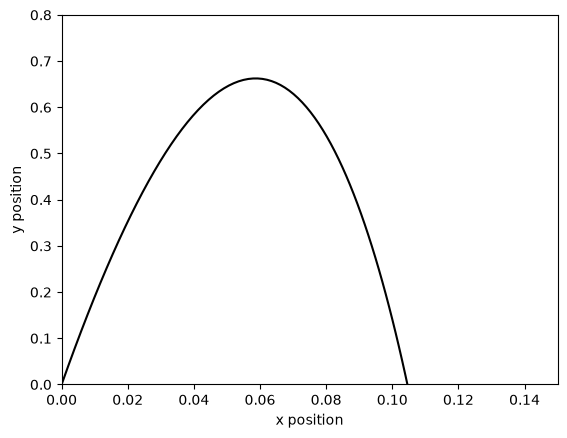

In [1]:
import matplotlib.pyplot as plt
import numpy as np

dt = 0.01 # in seconds
t_range = np.arange(0,1,dt)

g = 9.8
mass = 2.0
b = 1  # /s

def move(xpos, xvel, zpos, zvel, dt):
    xpos = xpos + xvel * dt
    zpos = zpos + zvel * dt
    zvel = zvel + (-g-b*zvel) * dt
    xvel = xvel + (-b*xvel) *dt
    return xpos, xvel, zpos, zvel

#initialize particle state
xpos=0
xvel=0.2
zpos=0
zvel=4.0
xn=[xpos]
zn=[zpos]

for t in t_range:
    xpos, xvel, zpos, zvel = move(xpos, xvel, zpos, zvel, dt)
    xn.append(xpos)
    zn.append(zpos)

fig, ax = plt.subplots(1)
ax.plot(xn,zn,'k-')
ax.set_xlim(0,0.15)
ax.set_ylim(0,0.8)
ax.set_ylabel('z position')
ax.set_xlabel('x position')
plt.show()

Now we'll implement the Runge-Kutta method at 2nd order. It's easier to work backwards, starting from what we need at the end: update every variable by their time derivative taken at the midpoint between `t` and `t+dt`.

In [ ]:
    # At the end (at t + dt)


Now we need to calulate these time derivatives. All the accelerations are calculated at the same instant in time, whereas all the velocities are propogated from time `t` by `dt/2`

In [ ]:
    # In the middle (at t+dt/2)

And finally, at the very beginning, we need to calculate the accelerations at time `t`

In [12]:
    # At the start (at time t)

Putting everything together, our code now looks like the following. I have added a 

In [ ]:
# Complete Version 1 here


Notice that the RK2 method solution (blue dots) is very accurate even though the timestep is HUGE ($dt=0.1$ seconds)! This demonstrates the much smaller error of the Runge-Kutta 2nd order method.

Demonstration of $O(dt^2)$ global error behavior:

At `dt` = 0.1 s,  error $= 0.090-0.078 = 0.012$m

At `dt` = 0.05 s,  error $= 0.088-0.085 = 0.003$m



This concludes version 1 of our RK2 code to simulate projectile motion.

## Runge-Kutta method, Version 2 with  d/dt function separated out

In verison 1 of our projectile code, we've made it to work, using both Euler's method and the RK2 method. But as we'll see later, the structure of the code has a lot of room for improvement. Version 1 is the most explicit version we will ever see, so if you ever get lost in the abstractions in versions 2 and 3 later on, you can always revert back to this version to review the detailed workflow of the calculation.

Moving on to version 2 now. If you stare at the code for long enough, you may realize that the calculation of acceleration appears two times – once in Euler's method and once in RK2. In version 2 we will try to define this calculation only once. This is done by the the `diffeq()` function below.

In [2]:
def diffeq(xpos, xvel, zpos, zvel):
    #YOUR CODE HERE

In [3]:
#move() functions here

Does the code look more organized? We can now clearly see the structure of the two ODE solver methods. The function `diffeq()` essentially serves to calculate the time derivative of every variable – in intakes positions and velocities and returns velocities and accelerations.

In Euler, we call `diffeq()` once and propagate time by $dt$. In RK2, we call `diffeq()` once, propagate time by $dt/2$, call diffeq() a second time, and propagate time by dt. The better accuracy of RK2 comes at the price of twice as many calculations (compared to what is needed for Euler). This concludes version 2.

In [ ]:
# Complete Version 2 here

Now seeing that the structure contains blocks of something = something + \[something's time derivative\] $\times dt$, we're curious if these blocks can be compacted even further. This is what we'll do in version 3. Our goal is to write everything as a vector like `y = [xpos, xvel, zpos, zvel]`, and `ydot = [xvel, xacc, zvel, zacc]`, so that instead of writing

In [ ]:
    xpos = xpos + xvel * dt
    xvel = xvel + xacc * dt
    zpos = zpos + zvel * dt
    zvel = zvel + zacc * dt

we can simply write

In [ ]:
y = y + ydot * dt

## Runge-Kutta method, Version 3 with Vectorization

Now that we are introduced to numpy arrays and know that we can use them to quickly perform vector operations, let's implement numpy arrays in our Runge-Kutta method to make it more general and concise.

We'll replace every occurence of `xpos, xvel, zpos, zvel` with the vector `y`, represented in python by a numpy array. Similarly, we'll replace every occurence of `xvel, xacc, zvel, zacc` with `ydot`. Don't forget to use `np.array()` so that the vectors can be operated on as a whole.

In [ ]:
#YOUR CODE HERE

Notice that, at this point, our ODE solver is abstract and general enough to apply to **any** problem, no matter how many dimesions or particles there are. All that the move_Euler() and move_RK2() functions can see is an abstract vector called $y$. And it's up to us to design what $y$ really means outside these functions.


The final code looks like the following, and should generate the exact same figure.

In [ ]:
# Complete Version 3 here


<div class="span alert alert-info">

**Common error**: If you see an error message like 
<div class="span alert alert-warning">
UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'
</div>
you probably have a line like 
<div class="span alert alert-warning">
y += ydot * dt
</div>
If you expand it back to 
<div class="span alert alert-warning">
y = y + ydot * dt
</div>
the error will be resolved. This is very subtle error: Why is it that $x += 1 $ works for scalars but not on numpy arrays? To answer this we'll have to use concepts that appear later in the course, so it's okay to skip this for now. If you're curious, here it goes. Turns out that "+" and "+=" are two different methods. When we write y += ydot * dt, it means to carry out the right-hand-side operation and modify the contents of the left-hand-side's memory. So if your y vector starts out containing only integers like [0,3,0,10], then changing that into floats it not something numpy likes, therefore numpy throw an error. If you do y = y + ydot * dt, the RHS operation produces a result that is assigned to a new location in memory, which is allowed. 

For more details see [this link](https://stackoverflow.com/questions/35910577/why-does-python-numpys-mutate-the-original-array).

## Exercise
Now that we've finalized our project code, let's work on two applications. A projectile starts from the origin where the magnitude of its velocity is 30 m/s. You have the freedom of choosing the angle you launch it.


**Problem 1**. What angle should we choose if we need to hit a target at ground level 20m away from the origin? 

**Problem 2**. What angle should we choose if we want to reach as far as possible? How far can we reach?

No need of any analytical pen-on-paper calculation. Try to make use of the existing code we have right now. 


At this point in our class most of you have decided to simulate the projectile's motion for a range of angles and find out which angle(s) solve your problem. The end result may look something like the figure below.


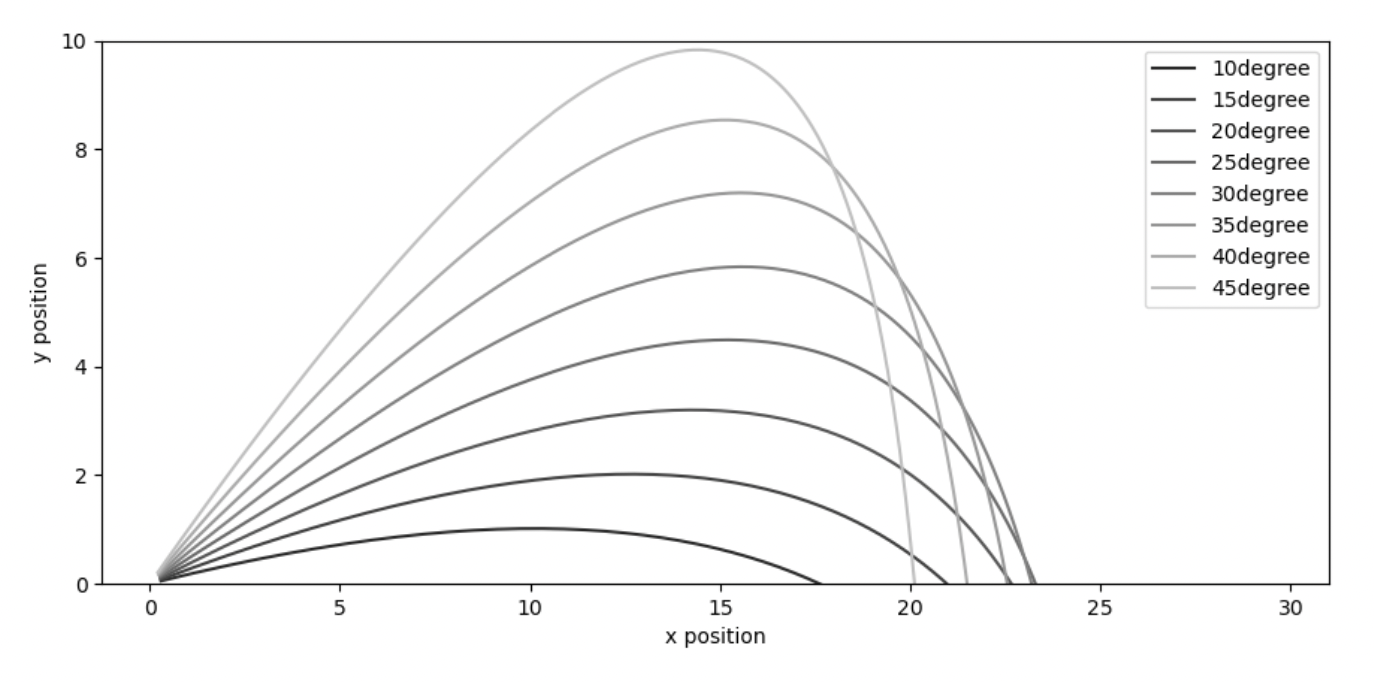

<div class="span alert alert-info">

**Troubleshooting tips for some common errors.**

**Q:** I'm seeing too many figures pop up.

**A:** Make sure that your "fig, ax = plt.subplots(1)" line or "plt.figure()" line are initiated only once before and outside any loop. They are responsible for creating a new plot, so if they are inside a loop you'll keep generating new figures in new windows.

**Q:** Some of my projectiles are not reaching the ground.

**A:** The simulation ended too early. Think about how to control the simulation time.

**Q:** I don't know where my projectile is and can't find it on any figure.

**A:** When in doubt, you can always print out the trajectory (xpos,zpos,etc.) in your console to look at the actual numbers. Are they not updating / going too far / going to slow? And then check back with your code.



Last but not least, in our course we will not focus on `scipy`'s `solve_ivp` function, since it is hiding lots of technical tricks under the hood. But here's a quick demo of how it works.

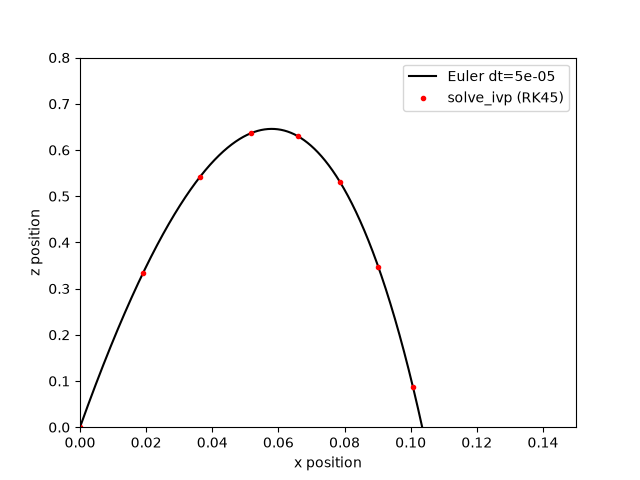

In [11]:
#solve_ivp variant
from scipy.integrate import solve_ivp

y0 = np.array([0, 0.2, 0, 4.0])  # xpos, xvel, zpos, zvel

sol = solve_ivp(diffeq, [0, 1], y0, method='RK45', dense_output=True,
                 rtol=1e-8, atol=1e-10)

t_eval = np.arange(0, 1, 0.1)
y_ivp = sol.sol(t_eval)
x_ivp = y_ivp[0]
z_ivp = y_ivp[2]

#plotting numerical
fig, ax = plt.subplots(1)
ax.plot(x_Euler,z_Euler,'k-')
ax.plot(x_ivp, z_ivp, 'r.')
ax.set_xlim(0,0.15)
ax.set_ylim(0,0.8)
ax.set_ylabel('z position')
ax.set_xlabel('x position')
ax.legend(['Euler dt='+str(dt_Euler),'solve_ivp (RK45)'])